Now that we have done data exploration and some feature engineering, let's move onto making models to predict pickleball matches.  In the end, we should see some features that stand out and are important to learn what decides the outcome of pickleball matches.  First, let's install the required libraries and upload our dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import random
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# 1. Load Data
df = pd.read_csv('matches_complete7.0.csv')

In [ ]:
df['Target'] = (df['WinningTeam'] == 'TeamA').astype(int)
final_features = [
    'DUPR_Diff',
    'Weak_Link_Diff',
    'Consistency_Diff',
    'Net_Efficiency_Diff',
    'Drive_Diff',
    'TeamA_Driver_Net_Synergy',
    'TeamB_Driver_Net_Synergy',
    'TeamA_DUPR_Synergy',
    'TeamB_DUPR_Synergy'
]

X = df[final_features].fillna(0)
y = df['Target']
split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
print(f"Training on first {len(X_train)} matches.")
print(f"Testing on final {len(X_test)} matches.")

Training on first 754 matches.
Testing on final 189 matches.


In [ ]:
baseline = LogisticRegression()
baseline.fit(X_train[['DUPR_Diff']], y_train)

y_prob_base = baseline.predict_proba(X_test[['DUPR_Diff']])[:, 1]
y_pred_base = baseline.predict(X_test[['DUPR_Diff']])

base_log_loss = log_loss(y_test, y_prob_base)
base_acc = accuracy_score(y_test, y_pred_base)

print(f"Baseline Log Loss: {base_log_loss:.4f}")
print(f"Baseline Accuracy: {base_acc:.4f}")

Baseline Log Loss: 0.6964
Baseline Accuracy: 0.4762


In [ ]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(xgb, param_grid, scoring='neg_log_loss', cv=3)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_

xgb_log_loss = log_loss(y_test, best_model.predict_proba(X_test)[:, 1])
xgb_acc = accuracy_score(y_test, best_model.predict(X_test))

print(f"XGBoost Log Loss: {xgb_log_loss:.4f}")
print(f"XGBoost Accuracy: {xgb_acc:.4f}")

XGBoost Log Loss: 0.3601
XGBoost Accuracy: 0.8148


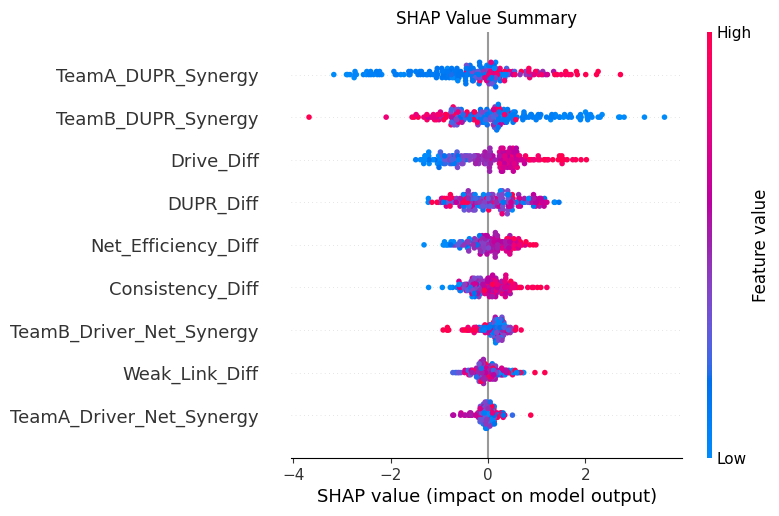

In [ ]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Value Summary')
plt.show()

In [ ]:
def simulate_point_markov():
    transitions = {
        'Serve': {'Return': 0.90, 'Point_Server': 0.05, 'Point_Receiver': 0.05},
        'Return': {'Third_Shot_Drop': 0.60, 'Third_Shot_Drive': 0.20, 'Point_Server': 0.15, 'Point_Receiver': 0.05},
        'Third_Shot_Drop': {'Dinking': 0.70, 'Point_Server': 0.10, 'Point_Receiver': 0.20},
        'Third_Shot_Drive': {'Hand_Battle': 0.50, 'Point_Server': 0.20, 'Point_Receiver': 0.30},
        'Dinking': {'Dinking': 0.60, 'Hand_Battle': 0.20, 'Point_Server': 0.10, 'Point_Receiver': 0.10},
        'Hand_Battle': {'Hand_Battle': 0.30, 'Point_Server': 0.35, 'Point_Receiver': 0.35}
    }

    current_state = 'Serve'

    for _ in range(50):
        if current_state in ['Point_Server', 'Point_Receiver']:
            break

        probs = transitions[current_state]
        current_state = random.choices(list(probs.keys()), weights=list(probs.values()))[0]

    return current_state

# Run 1000 simulations
results = [simulate_point_markov() for _ in range(1000)]
server_win_pct = results.count('Point_Server') / 1000
print(f"Markov Simulation Server Win Rate: {server_win_pct:.1%}")

Markov Simulation Server Win Rate: 47.6%
